# 7.2. Convolutions for Images

Let's build a simple, minimal example of a convolutional layer to understand what it does and why we might need it for non-trivial image classification tasks involving many large, colored, high-resolution images. As usual, the software we need is listed below.

1. Python 3.12
1. MindSpore 2.8.0
1. CANN 8.5.0

In [1]:
!cat requirements.txt

absl-py==2.4.0
attrs==26.1.0
cloudpickle==3.1.2
decorator==5.2.1
jupyterlab==4.5.7
jupyterlab-git==0.53.0
jupyter-resource-usage==1.2.1
mindspore==2.8.0
ml-dtypes==0.5.4
sympy==1.14.0
tornado==6.5.5


In [2]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import mindspore

mindspore.set_device(device_target='Ascend', device_id=0)
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


## 7.2.1. The Cross-Correlation Operation

Consider the following matrices.

1. Input "image": $\mathbf{X} = \bigl( \begin{smallmatrix} 0 & 1 & 2 \\ 3 & 4 & 5 \\ 6 & 7 & 8 \end{smallmatrix} \bigr)$
1. Convolutional kernel: $\mathbf{K} = \bigl( \begin{smallmatrix} 0 & 1 \\ 2 & 3 \end{smallmatrix} \bigr)$

We can obtain the output $\mathbf{Y} = \mathbf{X} \ast \mathbf{K} = \bigl( \begin{smallmatrix} 0 \times 0 + 1 \times 1 + 3 \times 2 + 4 \times 3 & 1 \times 0 + 2 \times 1 + 4 \times 2 + 5 \times 3 \\ 3 \times 0 + 4 \times 1 + 6 \times 2 + 7 \times 3 & 4 \times 0 + 5 \times 1 + 7 \times 2 + 8 \times 3 \end{smallmatrix} \bigr) = \bigl( \begin{smallmatrix} 19 & 25 \\ 37 & 43 \end{smallmatrix} \bigr)$ by shifting the kernel across our "image" and summing the elementwise products of both matrices. This is known as _cross-correlation_.

Notice the resulting matrix is smaller than our input "image". In general, given an image $\mathbf{X}_{n_h \times n_w}$ and kernel $\mathbf{K}_{k_h \times k_w}$, the resulting matrix $\mathbf{Y}$ has shape $(n_h - k_h + 1) \times (n_w - k_w + 1)$.

Let's see an implementation of the above with MindSpore.

In [4]:
import mindspore.ops as ops
from mindspore import dtype as mstype

def corr2d(X, K):
    """Compute 2D cross-correlation."""
    h, w = K.shape
    Y = ops.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = ops.sum(X[i:i+h, j:j+w] * K)
    return Y

X = ops.reshape(ops.arange(9), (3, 3))
K = ops.reshape(ops.arange(4), (2, 2))
Y = corr2d(X, K).astype(dtype=mstype.int64)
X, K, Y

/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
2026-05-02 13:17:26.472872: E external/org_tensorflow/tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute is_closed which is not in the op definition: Op<name=Range; signature=start:Tidx, limit:Tidx, delta:Tidx -> output:Tidx; attr=Tidx:type,default=DT_INT32,allowed=[DT_BFLOAT16, DT_HALF, DT_FLOAT, DT_DOUBLE, DT_INT8, DT_INT16, DT_INT32, DT_INT64, DT_UINT16, DT_UINT32]> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Range1}}


(Tensor(shape=[3, 3], dtype=Int64, value=
 [[0, 1, 2],
  [3, 4, 5],
  [6, 7, 8]]),
 Tensor(shape=[2, 2], dtype=Int64, value=
 [[0, 1],
  [2, 3]]),
 Tensor(shape=[2, 2], dtype=Int64, value=
 [[19, 25],
  [37, 43]]))

## 7.2.2. Convolutional Layers

We are now ready to implement our first convolutional layer. Define the kernel matrix $\mathbf{K}$ and scalar bias $b$. Our convolutional layer computes the output matrix $\mathbf{Y}$ defined below.

$$
\begin{align}
\mathbf{Y} = \mathbf{X} \ast \mathbf{K} + b
\end{align}
$$

Notice how similar it is to our fully connected layer, except the weight vector $\mathbf{w}$ is replaced with the kernel matrix $\mathbf{K}$ and matrix-vector multiplication is replaced with the cross-correlation operation.

As usual, we default to initializing our kernel $\mathbf{K}$ with random weights from the standard normal distribution and the scalar bias $b$ to zero. [`mindspore.nn.Conv2d`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/nn/mindspore.nn.Conv2d.html) is already defined by MindSpore so let's call our convolutional layer `MyConv2d`.

In [5]:
import mindspore.nn as nn

class MyConv2d(nn.Cell):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = mindspore.Parameter(ops.randn(*kernel_size))
        self.bias = mindspore.Parameter(ops.zeros(1))

    def construct(self, X):
        y_hat = corr2d(X, self.weight) + self.bias
        return y_hat

my_conv2d_layer = MyConv2d(kernel_size=(1, 2))
my_conv2d_layer

MyConv2d()

## 7.2.3. Object Edge Detection in Images

Let's create an "image" with vertical edges and design a kernel to detect these vertical edges.

In [6]:
X = ops.ones((6, 8))
X[:, 2:6] = 0
X

Tensor(shape=[6, 8], dtype=Float32, value=
[[ 1.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
 [ 1.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
 [ 1.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
 [ 1.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
 [ 1.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00,  1.00000000e+00,  1.00000000e+00],
 [ 1.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00,  1.00000000e+00,  1.00000000e+00]])

The above "image" `X` has 4 columns filled with zeroes in the middle and the remaining columns filled with ones.

Now we define our kernel $\mathbf{K}_{1 \times 2} = \bigl( \begin{smallmatrix} 1 & -1 \end{smallmatrix} \bigr)$ which compares 2 adjacent elements horizontally with the following behavior.

1. If both adjacent elements are the same, i.e. both ones or both zeroes, then the result is $0$
1. Otherwise, if both adjacent elements differ, the result is nonzero, specifically $\pm 1$

In [7]:
K = mindspore.Tensor([[1.0, -1.0]])
K

Tensor(shape=[1, 2], dtype=Float32, value=
[[ 1.00000000e+00, -1.00000000e+00]])

Applying the cross-correlation operation to our "image" and kernel yields the following result.

1. Horizontally adjacent columns where the values are both ones or both zeroes yield zeroes in the resulting _feature map_, indicating the absence of a vertical edge
1. Conversely, horizontally adjacent columns with alternating values, i.e. left column all zeroes and right column all ones or vice versa, yield nonzero values in the resulting feature map, indicating the presence of a vertical edge

In [8]:
Y = corr2d(X, K)
Y

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result


Tensor(shape=[6, 7], dtype=Float32, value=
[[ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
 [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
 [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
 [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
 [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
 [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00, -1.00000000e+00,  0.00000000e+00]])

Let's try applying our kernel to our transposed image with horizontal edges instead of vertical edges and inspect the result.

In [9]:
corr2d(ops.transpose(X, (1, 0)), K)

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result


Tensor(shape=[8, 5], dtype=Float32, value=
[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
 [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
 [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
 ...
 [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
 [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
 [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

Since our kernel detects vertical edges only, we get a zero matrix applying the same kernel to our transposed image which only has horizontal edges.

## 7.2.4. Learning a Kernel

Designing our kernel _a priori_ based on the features we want to extract is commonly known as feature engineering. For simple features, such an approach may be feasible and computationally efficient. However, for extracting complex features, designing our kernel based on human intuition alone is simply no longer viable. Instead, we can have our convolutional layer learn the kernel for us.

In [10]:
loss_fn = nn.MSELoss()
loss_fn

MSELoss()

In [11]:
optimizer = nn.SGD(params=my_conv2d_layer.trainable_params(), learning_rate=0.1)
optimizer

SGD()

In [12]:
def forward(X, Y):
    Y_hat = my_conv2d_layer(X)
    loss = loss_fn(Y_hat, Y)
    return loss, Y_hat

In [13]:
grad_fn = mindspore.value_and_grad(fn=forward, grad_position=None, weights=optimizer.parameters, has_aux=True)
grad_fn

<function mindspore.ops.composite.base._Grad.__call__.<locals>.after_grad(*args, **kwargs)>

In [14]:
epochs = 100

In [15]:
training_losses = []
my_conv2d_layer.set_train()
for epoch in range(epochs):
    print(f'Epoch {epoch} start')
    (loss, _), grads = grad_fn(X, Y)
    optimizer(grads)
    print(f'Training loss: {loss.asnumpy():.4f}')
    training_losses.append(loss)
    print(f'Epoch {epoch} end')

training_losses = ops.stack(training_losses)
training_losses.shape

Epoch 0 start


/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: Sy

.Training loss: 0.2154
Epoch 0 end
Epoch 1 start
Training loss: 0.1748
Epoch 1 end
Epoch 2 start
Training loss: 0.1506
Epoch 2 end
Epoch 3 start
Training loss: 0.1348
Epoch 3 end
Epoch 4 start
Training loss: 0.1234
Epoch 4 end
Epoch 5 start
Training loss: 0.1144
Epoch 5 end
Epoch 6 start
Training loss: 0.1068
Epoch 6 end
Epoch 7 start
Training loss: 0.1000
Epoch 7 end
Epoch 8 start
Training loss: 0.0939
Epoch 8 end
Epoch 9 start
Training loss: 0.0883
Epoch 9 end
Epoch 10 start
Training loss: 0.0830
Epoch 10 end
Epoch 11 start
Training loss: 0.0781
Epoch 11 end
Epoch 12 start
Training loss: 0.0735
Epoch 12 end
Epoch 13 start
Training loss: 0.0692
Epoch 13 end
Epoch 14 start
Training loss: 0.0651
Epoch 14 end
Epoch 15 start
Training loss: 0.0613
Epoch 15 end
Epoch 16 start
Training loss: 0.0577
Epoch 16 end
Epoch 17 start
Training loss: 0.0543
Epoch 17 end
Epoch 18 start
Training loss: 0.0512
Epoch 18 end
Epoch 19 start
Training loss: 0.0482
Epoch 19 end
Epoch 20 start
Training loss: 0.0

(100,)

Plot the training losses with Matplotlib.

In [16]:
import numpy as np

epochs_x = np.arange(epochs)
training_losses_y = training_losses.asnumpy()
epochs_x.shape, training_losses_y.shape

.

((100,), (100,))

In [17]:
%pip install matplotlib==3.10.9


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


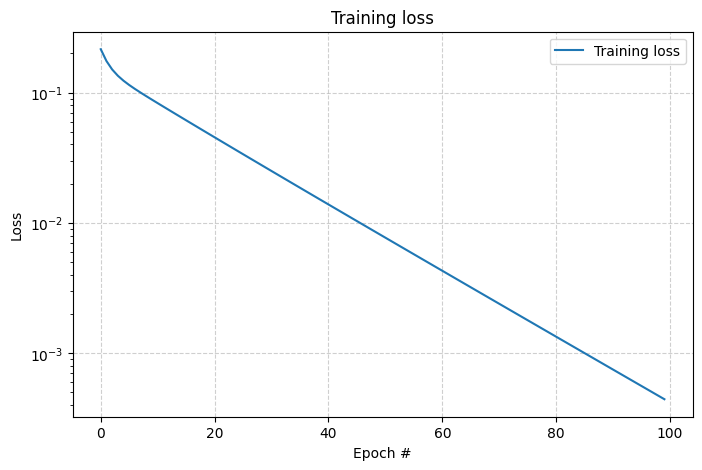

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(epochs_x, training_losses_y, label='Training loss', linestyle='-')

plt.title('Training loss')
plt.xlabel('Epoch #')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

Let's inspect the kernel learned by our custom convolutional layer derived from first principles.

In [19]:
my_conv2d_layer.weight.data

Tensor(shape=[1, 2], dtype=Float32, value=
[[ 9.60622132e-01, -9.62981939e-01]])

As seen from the given output, our learned kernel $\mathbf{\hat{K}} \approx \mathbf{K} = \bigl( \begin{smallmatrix} 1 & -1 \end{smallmatrix} \bigr)$. Not bad!

Let's predict the feature map $\mathbf{\hat{Y}}$ as well and see how close it is to the expected feature map $\mathbf{Y}$.

In [20]:
my_conv2d_layer.set_train(False)
Y_hat = my_conv2d_layer(X)
loss = loss_fn(Y_hat, Y)
print(f'Validation loss: {loss.asnumpy():.4f}')
Y_hat, Y

Validation loss: 0.0004


(Tensor(shape=[6, 7], dtype=Float32, value=
 [[-1.03874481e-03,  9.61943209e-01,  1.32106268e-03 ...  1.32106268e-03, -9.61660862e-01, -1.03874481e-03],
  [-1.03874481e-03,  9.61943209e-01,  1.32106268e-03 ...  1.32106268e-03, -9.61660862e-01, -1.03874481e-03],
  [-1.03874481e-03,  9.61943209e-01,  1.32106268e-03 ...  1.32106268e-03, -9.61660862e-01, -1.03874481e-03],
  [-1.03874481e-03,  9.61943209e-01,  1.32106268e-03 ...  1.32106268e-03, -9.61660862e-01, -1.03874481e-03],
  [-1.03874481e-03,  9.61943209e-01,  1.32106268e-03 ...  1.32106268e-03, -9.61660862e-01, -1.03874481e-03],
  [-1.03874481e-03,  9.61943209e-01,  1.32106268e-03 ...  1.32106268e-03, -9.61660862e-01, -1.03874481e-03]]),
 Tensor(shape=[6, 7], dtype=Float32, value=
 [[ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
  [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00 ...  0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
  [ 0.00000000e+00,  1.00000000e+00,  

## 7.2.7. Summary

We defined our first convolutional layer from first principles and saw it in action, training it against a feature map obtained from a predefined kernel which extracts vertical edges from our image. We inspected the resulting learned kernel from our convolutional layer after 100 epochs of training and saw how it relates to our predefined kernel, demonstrating that kernels need not be pre-constructed from human intuition and can instead be learned just like weights in fully connected layers.